In [35]:
### Basic Deep Agent
import os
from dotenv import load_dotenv,find_dotenv
load_dotenv(find_dotenv())


True

In [36]:
os.environ["OPENAI_API_kEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [37]:
##-------- tool for internet search ----------##
import os 

from tavily import TavilyClient
from typing import Literal
from langchain_core.tools import tool

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
@tool
def websearch(query:str, max_result: int=5, topic: Literal["news","general"]='general', include_raw_content=False) ->dict:
    """ run a web search """
    return tavily_client.search(query=query, max_results=max_result, topic=topic, include_raw_content=include_raw_content)




In [38]:
# load llm model
from langchain.chat_models import init_chat_model

model= init_chat_model("groq:openai/gpt-oss-20b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002E66CF8E330>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002E66CF8EC30>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

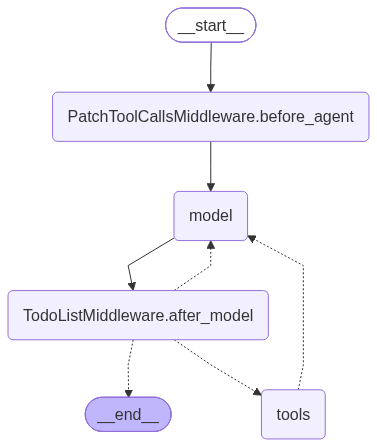

In [39]:
""" Create a deep agent

1-prompt

2- define agent
 """

from deepagents import create_deep_agent
from langchain.agents.middleware import TodoListMiddleware

deep_agent = create_deep_agent(
    model=model,
    tools=[websearch],
    system_prompt="Act as a researcher",
    middleware=[TodoListMiddleware()],

)
deep_agent

In [48]:
response = deep_agent.invoke({"messages":[{"role":"user","content":"what is langgraph? tell me about it everything, do not wait for our queston just give me aswer "}]})


In [50]:
response["messages"][-1].content



'**LangGraph: A Comprehensive Overview**\n\n---\n\n### 1. What Is LangGraph?\n\nLangGraph is an open‑source framework designed to build *graph‑based conversational agents* that can orchestrate large language models (LLMs) and other services in a flexible, modular way. It sits on top of the LangChain ecosystem (hence the “Lang” prefix) and extends it by providing a *stateful, event‑driven graph* that represents the flow of data, prompts, and actions in a conversation or workflow.\n\nKey ideas:\n\n- **Graph‑oriented architecture**: Nodes represent *states* or *actions*; edges represent *transitions* triggered by events or conditions.\n- **Stateful LLM interactions**: Instead of a single prompt, the framework maintains a mutable conversation state that can be enriched, refined, or split across multiple LLM calls.\n- **Modular components**: Any tool—LLM, API call, database query, custom function—can be plugged into nodes.\n- **Declarative workflow**: Define your agent’s logic with a concis

In [43]:
print(deep_agent.get_input_schema().schema())

{'$defs': {'AIMessage': {'additionalProperties': True, 'description': 'Message from an AI.\n\nAn `AIMessage` is returned from a chat model as a response to a prompt.\n\nThis message represents the output of the model and consists of both\nthe raw output as returned by the model and standardized fields\n(e.g., tool calls, usage metadata) added by the LangChain framework.', 'properties': {'content': {'anyOf': [{'type': 'string'}, {'items': {'anyOf': [{'type': 'string'}, {'additionalProperties': True, 'type': 'object'}]}, 'type': 'array'}], 'title': 'Content'}, 'additional_kwargs': {'additionalProperties': True, 'title': 'Additional Kwargs', 'type': 'object'}, 'response_metadata': {'additionalProperties': True, 'title': 'Response Metadata', 'type': 'object'}, 'type': {'const': 'ai', 'default': 'ai', 'title': 'Type', 'type': 'string'}, 'name': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Name'}, 'id': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'defaul